# Laptop Price Prediction using Machine Learning

PROBLEM STATEMENT

The increasing variety of laptops with different configurations such as processor type, RAM, storage, and graphics has made it difficult to estimate their prices accurately. The relationship between these features and the final price is complex and not easily understood through manual analysis. This project aims to develop a machine learning model that can predict laptop prices based on their specifications. By applying data preprocessing, feature engineering, and regression algorithms, the system seeks to provide accurate price predictions and help in better decision-making for buyers and sellers.

In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [113]:
df = pd.read_csv('laptopPrice.csv')
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


## Data Preprocessing


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [115]:
df.describe()

,Price,Number of Ratings,Number of Reviews
count,823.000000,823.000000,823.000000
mean,76745.177400,315.301337,37.609964
std,45101.790525,1047.382654,121.728017
min,16990.000000,0.000000,0.000000
25%,46095.000000,0.000000,0.000000
50%,64990.000000,17.000000,2.000000
75%,89636.000000,139.500000,18.000000
max,441990.000000,15279.000000,1947.000000


In [116]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


In [117]:
# Convert everything to string FIRST
df['ram_gb'] = df['ram_gb'].astype(str).str.extract(r'(\d+)').astype(float)
df['ssd'] = df['ssd'].astype(str).str.extract(r'(\d+)').astype(float)
df['hdd'] = df['hdd'].astype(str).str.extract(r'(\d+)').astype(float)
df['graphic_card_gb'] = df['graphic_card_gb'].astype(str).str.extract(r'(\d+)').astype(float)
df['rating'] = df['rating'].astype(str).str.extract(r'(\d+)').astype(float)

##EDA

In [118]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              823 non-null    object 
 1   processor_brand    823 non-null    object 
 2   processor_name     823 non-null    object 
 3   processor_gnrtn    823 non-null    object 
 4   ram_gb             823 non-null    float64
 5   ram_type           823 non-null    object 
 6   ssd                823 non-null    float64
 7   hdd                823 non-null    float64
 8   os                 823 non-null    object 
 9   os_bit             823 non-null    object 
 10  graphic_card_gb    823 non-null    float64
 11  weight             823 non-null    object 
 12  warranty           823 non-null    object 
 13  Touchscreen        823 non-null    object 
 14  msoffice           823 non-null    object 
 15  Price              823 non-null    int64  
 16  rating             823 non

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


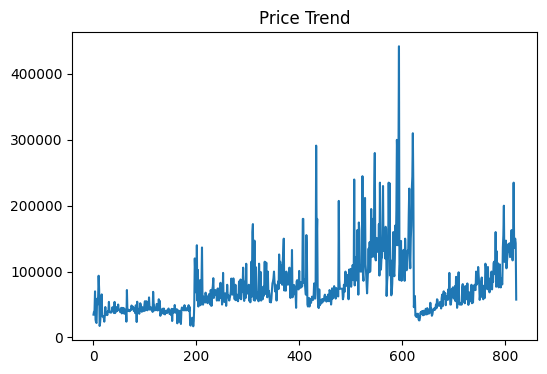

In [119]:
plt.figure(figsize=(6,4))
df['Price'].plot()
plt.title("Price Trend")
plt.show()

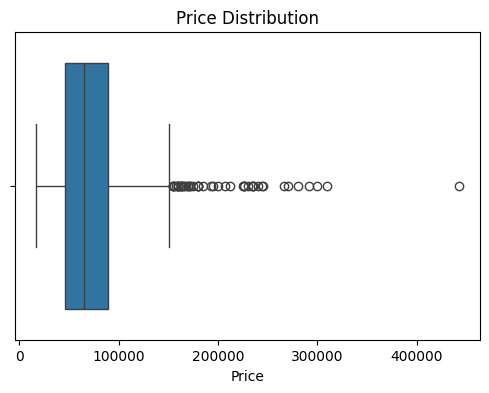

In [120]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Price Distribution")
plt.show()

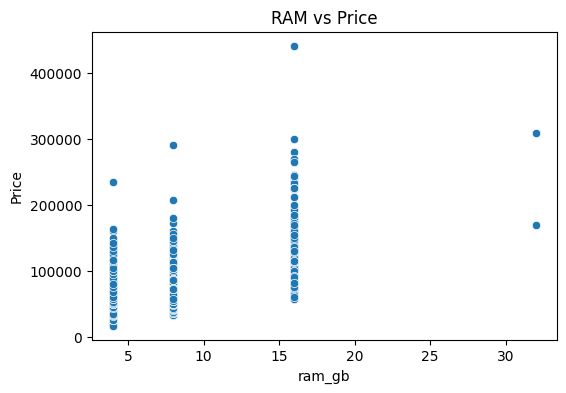

In [121]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['ram_gb'], y=df['Price'])
plt.title("RAM vs Price")
plt.show()

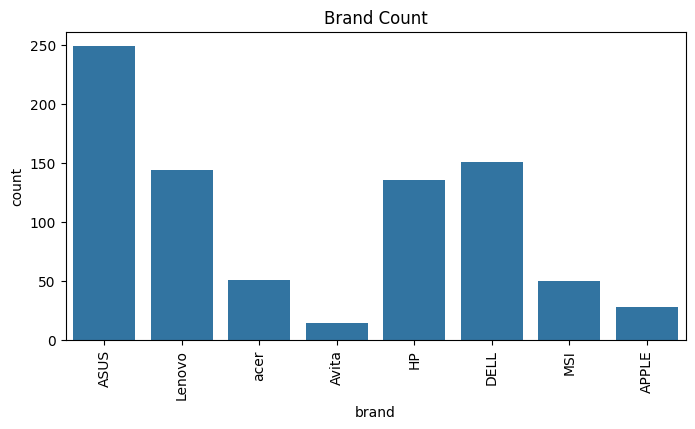

In [122]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['brand'])
plt.xticks(rotation=90)
plt.title("Brand Count")
plt.show()

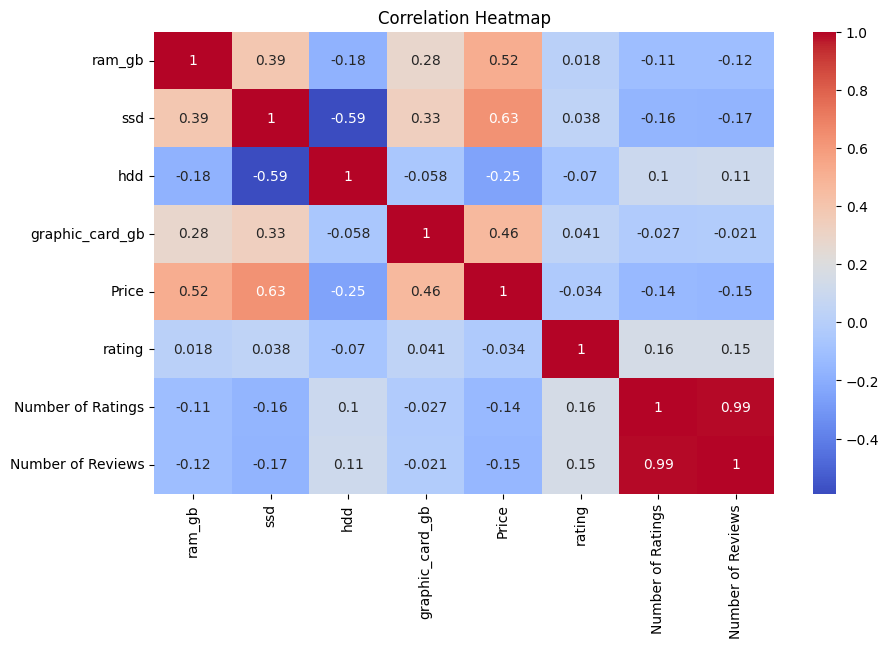

In [123]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##FEATURE ENGINEERING + ENCODING

In [124]:
df.fillna(0, inplace=True)

In [125]:
df['total_storage'] = df['ssd'] + df['hdd']
df['performance_score'] = df['ram_gb'] + df['graphic_card_gb']
df['price_per_gb'] = df['Price'] / (df['total_storage'] + 1)

In [126]:
def price_category(price):
    if price < 30000:
        return 0
    elif price < 60000:
        return 1
    else:
        return 2

df['price_class'] = df['Price'].apply(price_category)

In [127]:
df.drop(['Unnamed: 0'], axis=1, inplace=True, errors='ignore')

In [128]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [129]:
print(df.head())
print(df.dtypes)

   brand  processor_brand  processor_name  processor_gnrtn  ram_gb  ram_type  \
0      1                1               1                0     4.0         1   
1      5                1               1                0     4.0         1   
2      5                1               1                0     4.0         1   
3      1                1               2                0     8.0         1   
4      1                1               0                7     4.0         1   

     ssd     hdd  os  os_bit  ...  Touchscreen  msoffice  Price  rating  \
0    0.0  1024.0   2       1  ...            0         0  34649     2.0   
1    0.0  1024.0   2       1  ...            0         0  38999     3.0   
2    0.0  1024.0   2       1  ...            0         0  39999     3.0   
3  512.0     0.0   2       0  ...            0         0  69990     3.0   
4    0.0   512.0   2       1  ...            0         0  26990     3.0   

   Number of Ratings  Number of Reviews  total_storage  performance_

In [130]:
X = df.drop(['Price', 'price_class'], axis=1)

# Regression
y_reg = df['Price']

# Classification
y_clf = df['price_class']

## Train_Test split


In [131]:
from sklearn.model_selection import train_test_split

# Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

## Feature Scaling

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Regression
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

# Classification
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

## Model Selection

###Linear regression

[ 89481.21419759  60619.29248032  37695.92537918  36016.43821721
  59413.47250962  82309.57423587 137683.95707505  39597.72827653
  47560.91638768  46676.25138428]


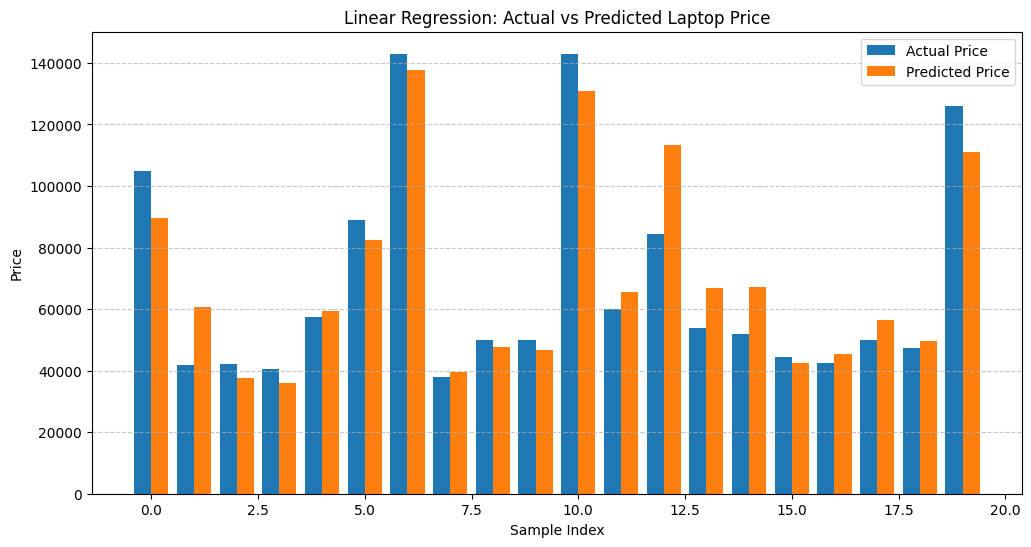

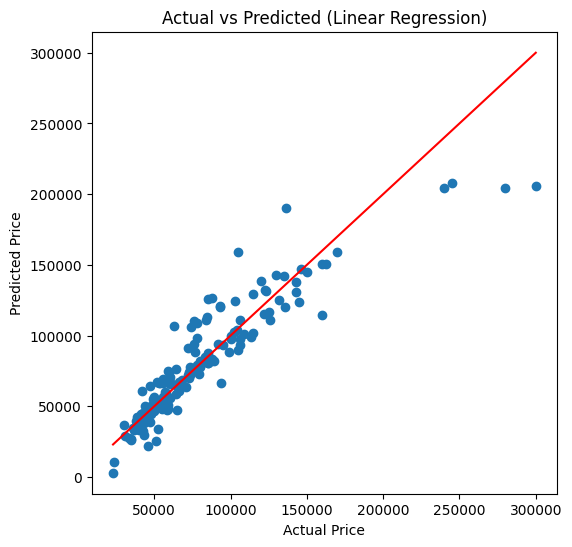

In [133]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# Predictions
lr_predictions = lr_model.predict(X_test_r)

print(lr_predictions[:10])

n = 20   # first 20 samples

x = np.arange(n)

plt.figure(figsize=(12,6))

plt.bar(x - 0.2, y_test_r.values[:n], width=0.4, label='Actual Price')
plt.bar(x + 0.2, lr_predictions[:n], width=0.4, label='Predicted Price')

plt.title("Linear Regression: Actual vs Predicted Laptop Price")
plt.xlabel("Sample Index")
plt.ylabel("Price")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

plt.figure(figsize=(6,6))

plt.scatter(y_test_r, lr_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression)")

plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         color='red')

plt.show()

###Decision Tree

In [134]:
# Target for regression
target = 'Price'

# Features & target
X = df.drop(columns=[target, 'price_class'])
y = df[target]

# Only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

[104990.  40990.  41990.  35990.  59990.  89390. 141990.  40890.  49990.
  49990.]


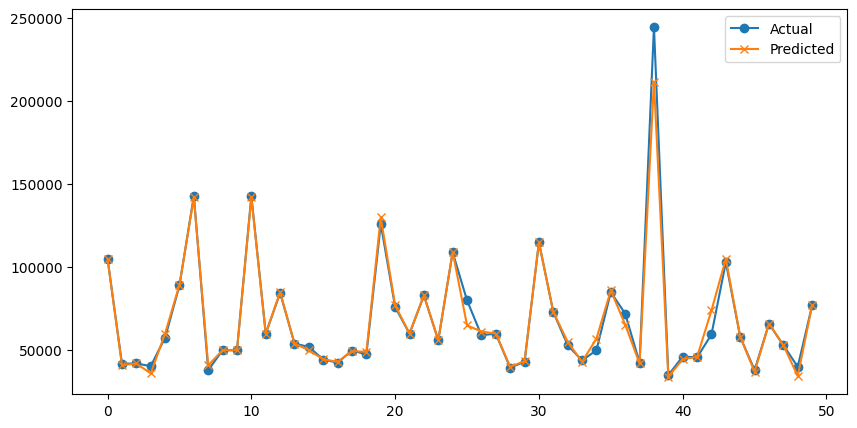

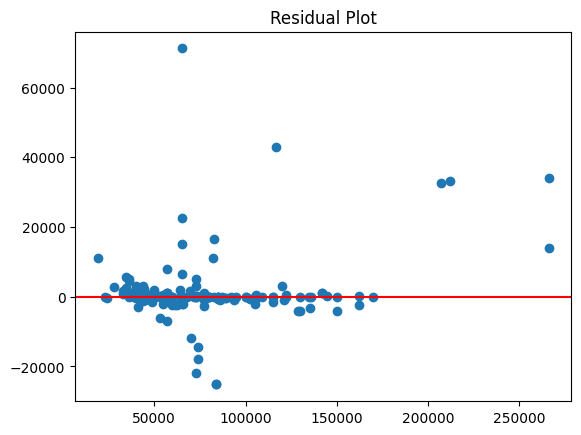

In [135]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
print(dt_predictions[:10])

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(dt_predictions[:50], label='Predicted', marker='x')
plt.legend()
plt.show()

residuals = y_test - dt_predictions

plt.scatter(dt_predictions, residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.show()

###KNN

[ 71890.   59494.   62391.8  49410.   68231.8  70429.8 139990.   45190.
  50071.8  55991.8]


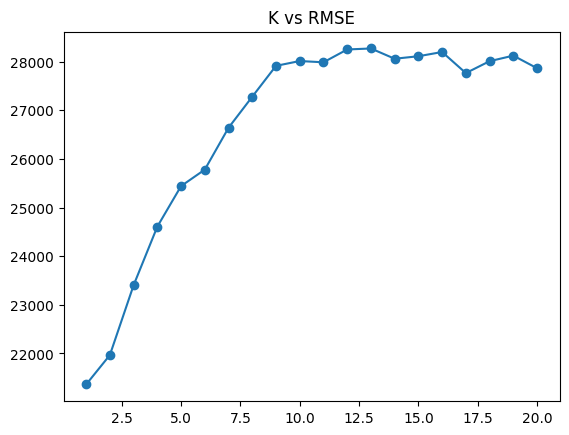

In [136]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)

print(knn_predictions[:10])

k_values = range(1,21)
rmse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    rmse.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.plot(k_values, rmse, marker='o')
plt.title("K vs RMSE")
plt.show()

###Gradient Boosting

In [137]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

gbr_predictions = gbr_model.predict(X_test)
print(gbr_predictions[:10])

[108613.67333379  41758.79120663  40221.71918732  40027.19107593
  60755.42016679  89556.2171356  137791.08630817  39268.63563938
  51662.24122073  50943.45854246]


###Randon Forest

In [138]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
print(rf_predictions[:10])

[104426.3   39803.75  40723.83  40054.13  62009.84  89130.35 141614.1
  37692.74  49712.    49634.08]


###XG Boost

In [139]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:10])

print("R2:", r2_score(y_test, xgb_predictions))

[106361.22   41906.707  39606.152  39988.355  60921.098  84973.97
 135082.69   40455.434  50523.707  50018.305]
R2: 0.9665402770042419


##Model Training and Testing

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbr_model,
    "KNN": knn_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 Score": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model           MAE          RMSE       R2 Score
5            XGBoost  3.920420e+03  8.075059e+03       0.966540
3  Gradient Boosting  4.426397e+03  8.344180e+03       0.964273
2      Random Forest  3.474105e+03  8.977130e+03       0.958647
1      Decision Tree  3.490564e+03  9.407612e+03       0.954586
4                KNN  1.566545e+05  1.712640e+05     -14.050932
0  Linear Regression  2.598210e+07  2.811206e+07 -405522.855519


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


In [141]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Pipeline R2:", r2_score(y_test, y_pred))

Pipeline R2: 0.9533773698405335


##HYPERPARAMETER TUNING

In [142]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None,10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 100}


##Feature Importence

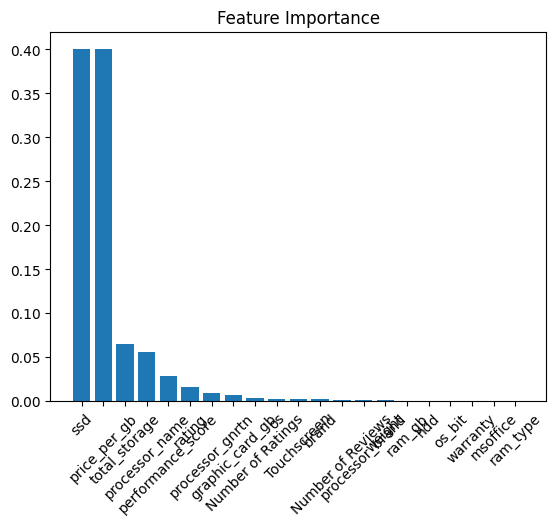

In [143]:
importance = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.bar(feat_df['Feature'], feat_df['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

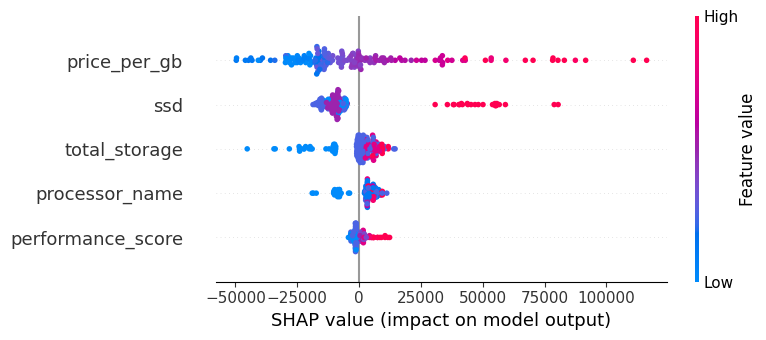

In [144]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap_values = np.array(shap_values)

shap.summary_plot(
    shap_values,
    X_test,
    max_display=5
)

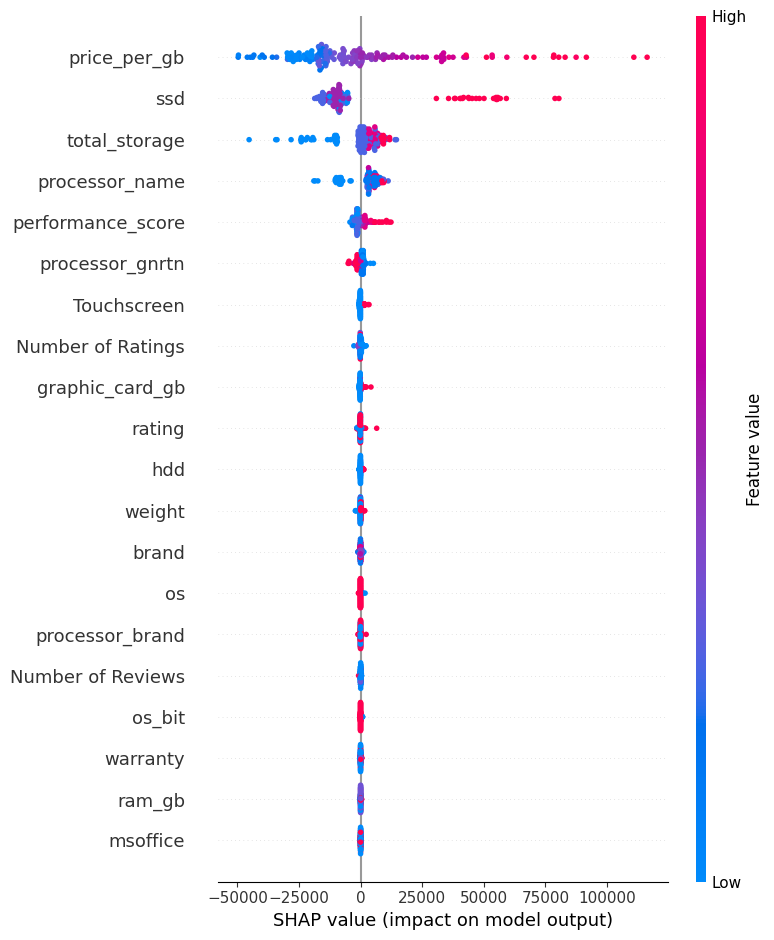

In [145]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

CONCLUSION

This project successfully developed a machine learning model to predict laptop prices based on their specifications. Data preprocessing and feature engineering improved the quality of the dataset, while multiple regression models were implemented and compared. Among them, ensemble methods like Random Forest and XGBoost performed better due to their ability to handle complex relationships. Visualization and feature importance analysis helped identify key factors influencing price. Overall, the project demonstrates the effectiveness of machine learning in accurate price prediction.